# Epoch Spring Camp 2026 - Take Home Task 3

In this task, you will build and compare two recommender system models:

- **Matrix Factorization (MF)** using a dot product of embeddings  
- **Neural Collaborative Filtering (MLP-based)** using a multi-layer perceptron  

You are provided with:
- Preprocessed interaction data
- Evaluation pipeline

You are expected to implement:
- Negative sampling
- Model architectures
- Training loop

---

The purpose of this task is to understand how neural networks can model user–item interactions beyond simple similarity.

## Imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import sys
import seaborn as sns
from sklearn.decomposition import PCA
import copy



In [3]:
seed = 42
rng = np.random.default_rng(seed)

if torch.cuda.is_available():
    device_ = 'cuda'
else:
    device_ = 'cpu'
torch.manual_seed(seed)

## Loading Data

We begin by loading the interaction data.

In [4]:
df = pd.read_csv("interactions.csv")
total_user = df['user_id'].nunique()
total_item = df['item_id'].nunique()

print("Num users:", total_user)
print("Num items:", total_item)
print("Num interactions:", len(df))
print(df.info())
print(df.head())

Num users: 942
Num items: 1447
Num interactions: 55375
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55375 entries, 0 to 55374
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  55375 non-null  int64
 1   item_id  55375 non-null  int64
dtypes: int64(2)
memory usage: 865.4 KB
None
   user_id  item_id
0        0        0
1        1        1
2        2        2
3        3        3
4        4        4


In [5]:
df.describe()

,user_id,item_id
count,55375.000000,55375.000000
mean,431.909725,333.916695
std,284.806639,275.753764
min,0.000000,0.000000
25%,150.000000,120.000000
50%,436.000000,261.000000
75%,670.000000,485.000000
max,941.000000,1446.000000


(array([10., 35., 58., 57., 62., 45., 52., 51., 30., 27., 25., 30., 37.,
        16., 37., 14., 20., 13.,  8., 10., 15., 13., 18.,  8., 17.,  6.,
        11., 11., 11.,  6.,  5.,  8., 11.,  4., 12.,  8.,  7.,  6.,  7.,
         4., 10.,  4.,  5.,  7.,  6.,  8.,  7.,  3.,  6.,  3.,  3.,  4.,
         2.,  2.,  3.,  3.,  8.,  1.,  3.,  1.,  0.,  2.,  3.,  1.,  0.,
         2.,  1.,  1.,  1.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  1.,  1.,
         0.,  1.,  0.,  4.,  1.,  0.,  0.,  1.,  2.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.]),
 array([  3.   ,   6.125,   9.25 ,  12.375,  15.5  ,  18.625,  21.75 ,
         24.875,  28.   ,  31.125,  34.25 ,  37.375,  40.5  ,  43.625,
         46.75 ,  49.875,  53.   ,  56.125,  59.25 ,  62.375,  65.5  ,
         68.625,  71.75 ,  74.875,  78.   ,  81.125,  84.25 ,  87.375,
         90.5  ,  93.625,  96.75 ,

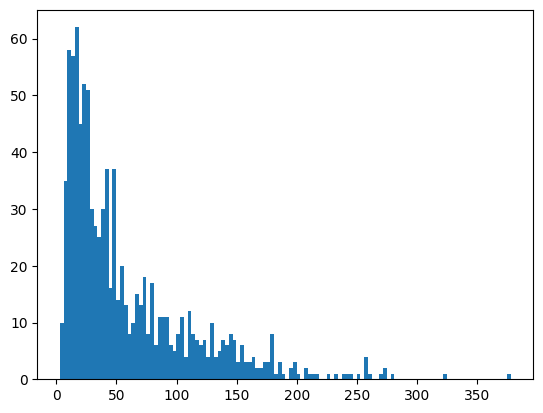

In [6]:
plt.hist(df['user_id'].value_counts(),bins=120) 

(array([491., 132., 110.,  66.,  51.,  40.,  54.,  42.,  38.,  27.,  27.,
         27.,  34.,  15.,  18.,  12.,  14.,  12.,  13.,   9.,  17.,   9.,
         13.,  16.,  11.,   7.,   9.,   6.,   2.,   6.,   6.,   5.,   6.,
          4.,   7.,   2.,  11.,   1.,   5.,   7.,   2.,   2.,   3.,   3.,
          6.,   3.,   1.,   3.,   0.,   1.,   3.,   2.,   2.,   5.,   2.,
          2.,   2.,   3.,   2.,   1.,   2.,   0.,   1.,   2.,   0.,   0.,
          0.,   1.,   0.,   0.,   2.,   1.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   2.,   1.,   1.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([  1.        ,   5.16666667,   9.33333333,  13.5       ,
         17.66666667,  21.83333333,  26.        ,  30.16666667,
         34.33333333,  38.5       ,  42.66666667,  46.83333333

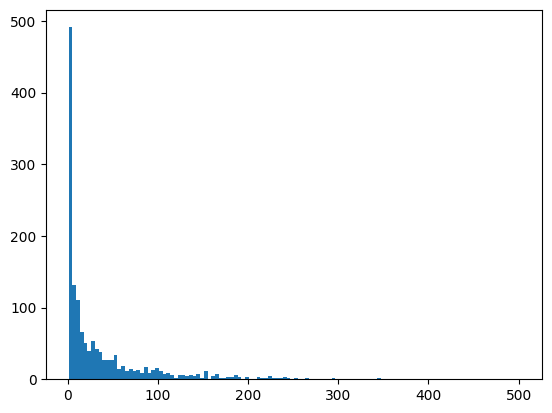

In [7]:
plt.hist(df['item_id'].value_counts(), bins=120)

Each row represents a **positive interaction** (implicit feedback).

## Train / Test Split

We split the data into training and testing sets.

The model will learn from the training data and be evaluated on unseen interactions in the test set.

In [8]:
from sklearn.model_selection import train_test_split

test_df = df.groupby('user_id').sample(n=1, random_state=seed)
rest_df = df.drop(test_df.index)

valid_df = rest_df.groupby('user_id').sample(n=1, random_state=seed)
train_df = rest_df.drop(valid_df.index)

print(f"Train size: {len(train_df)}")
print(f"Valid size: {len(valid_df)}")
print(f"Test size:  {len(test_df)}")


Train size: 53491
Valid size: 942
Test size:  942


## Negative Sampling

The dataset only contains **positive interactions** (user interacted with item).

However, to train a model, we also need **negative examples** (user did not interact with item).

---

### Why do we need this?

We treat recommendation as a **binary classification problem**:

- Positive interaction → label = 1  
- No interaction → label = 0  

Since we don’t have explicit negatives, we **sample them**.

---

### Your Task

For each `(user, item)` interaction:
- Keep it as a **positive sample (label = 1)**
- Sample one or more items the user has **not interacted with**
  - Add them as **negative samples (label = 0)**

---

### Hints

- You can randomly sample items
- Make sure sampled negatives are **not already in the dataset**
- You may use a `set` of `(user, item)` pairs for fast lookup

---

Implement a function:
`sample_negatives(df, num_neg=1)`
that returns a dataframe with columns:
`[user, item, label]`

In [9]:
def sample_negatives(df, num_neg=1):
    user_col = 'user_id' if 'user_id' in df.columns else 'user'
    item_col = 'item_id' if 'item_id' in df.columns else 'item'

    all_items = set(df[item_col].unique())
    interactions = set(zip(df[user_col], df[item_col]))
    user_interactions = df.groupby(user_col)[item_col].apply(set).to_dict()
    sampled_rows = []

    for user, pos_item in zip(df[user_col], df[item_col]):
        sampled_rows.append((user, pos_item, 1))

        candidates = list(all_items - user_interactions[user])
        if len(candidates) < num_neg:
            raise ValueError(f'User {user} does not have enough unseen items to sample {num_neg} negatives.')

        negatives = set()
        while len(negatives) < num_neg:
            neg_item = random.choice(candidates)
            if (user, neg_item) not in interactions and neg_item not in negatives:
                negatives.add(neg_item)

        for neg_item in negatives:
            sampled_rows.append((user, neg_item, 0))

    return pd.DataFrame(sampled_rows, columns=[user_col, item_col, 'label'])

## PyTorch Dataset

We now wrap our processed data into a PyTorch `Dataset`.

This allows us to:
- Access individual samples as `(user, item, label)`
- Easily plug into a `DataLoader` for batching

You do not need to modify this part.

In [10]:
class InteractionDataset(Dataset):
    def __init__(self, df, all_items, num_neg=4, alpha=10):
        self.users = df['user_id'].values.astype(int)
        self.pos_items = df['item_id'].values.astype(int)
        self.all_items = all_items.astype(int)
        self.num_neg = num_neg
        self.user_interacted = df.groupby('user_id')['item_id'].apply(set).to_dict()
        
        counts = df['user_id'].value_counts().to_dict()
        self.weights_map = {_: 1.0 / (count + alpha) for _, count in counts.items()}

    def __len__(self):
        return len(self.users) *(1 + self.num_neg)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.num_neg)
        is_pos = (idx % (1 + self.num_neg)) == 0
        u = self.users[pos_idx]

        if is_pos:
            _ = self.pos_items[pos_idx]
            label = 1.0
        else:
            _ = random.choice(self.all_items)
            interacted = self.user_interacted.get(u, set())
            while _ in interacted:
                _ = random.choice(self.all_items)
            label = 0.0

        weight = self.weights_map[u]

        return (torch.tensor(u, dtype=torch.long), 
                torch.tensor(_, dtype=torch.long), 
                torch.tensor(label, dtype=torch.float32),
                torch.tensor(weight, dtype=torch.float32)) 
    

In [11]:
class positive_interaction_dataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values.astype(np.int64))
        self.items = torch.tensor(df['item_id'].values.astype(np.int64))

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx]

## DataLoader

The `DataLoader` will:
- Batch the data
- Shuffle the training data
- Feed it to the model during training

In [12]:
valid_loader = DataLoader(InteractionDataset(valid_df,all_items=df['item_id'].unique(), 
                                             num_neg=10), batch_size=512, 
                                             shuffle=False)

train_loader = DataLoader(InteractionDataset(train_df,all_items=df['item_id'].unique(), 
                                            num_neg=10), batch_size=512, 
                                            shuffle=True)

valid_hit_loader = DataLoader(positive_interaction_dataset(valid_df), 
                              batch_size=512, 
                              shuffle=False)

Why are we sampling negatives only for the training data?

## Quick Exploration

Before building models, take a moment to explore the data.

Try to understand:
- How many interactions each user has
- How popular certain items are

This can give intuition about the dataset.

In [13]:
# Interactions per user
user_counts = df['user_id'].value_counts()
print(user_counts.describe())

# Interactions per item
item_counts = df['item_id'].value_counts()
print(item_counts.describe())

count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
Name: count, dtype: float64
count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: count, dtype: float64


## Baseline Model: Matrix Factorization (MF)

We represent:
- Each **user** as a vector (embedding)
- Each **item** as a vector (embedding)

To predict interaction:
- Compute the **dot product** between user and item embeddings

This gives a **score** indicating how likely the user is to interact with the item.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Computes their dot product as the output score

In [14]:
class MF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        # TODO:
        # - Define user embedding layer
        # - Define item embedding layer
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)    

    def forward(self, user, item):
        # TODO:
        # - Get user and item embeddings
        # - Compute dot product
        # - Return a single score per pair
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        return (user_emb*item_emb).sum(1)

## Training the MF Model

Now train your Matrix Factorization model.

You will need to:
- Define a loss function
- Define an optimizer
- Iterate over the DataLoader
- Update model parameters

---

### Hints

- Use **Binary Cross Entropy loss**
- Apply **sigmoid** to model outputs if needed
- Typical steps:
  - forward pass
  - compute loss
  - backward pass
  - optimizer step

In [15]:

def weighted_bce_loss(scores, labels, weights):
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    loss = criterion(scores, labels)
    normalized_weights = weights / weights.mean()
    return (loss * normalized_weights).mean()

def train(model, train_dataloader, epochs, val_dataloader=None, val_hit_dataloader=None,
          lr=1e-3, patience=3, K=10, num_neg_eval=100, num_items=None, device=None):
    if val_dataloader is None:
        val_dataloader = valid_loader
    if val_hit_dataloader is None:
        val_hit_dataloader = valid_hit_loader
    if num_items is None:
        num_items = model.item_emb.num_embeddings

    device = torch.device(device_)

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = weighted_bce_loss
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=max(1, patience // 2)
    )

    best_val_loss = float('inf')
    best_hit_rate = 0.0
    early_stop_counter = 0
    losses = []
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for user, item, label, weights in train_dataloader:
            user = user.to(device)
            item = item.to(device)
            label = label.to(device).float()
            weights = weights.to(device).float()

            optimizer.zero_grad()
            relevance_scores = model(user, item)
            loss = criterion(relevance_scores, label, weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for user, item, label, weights in val_dataloader:
                user = user.to(device)
                item = item.to(device)
                label = label.to(device).float()
                weights = weights.to(device).float()

                relevance_scores = model(user, item)
                loss = criterion(relevance_scores, label, weights)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)

        total_hits = 0
        total_eval_samples = 0
        with torch.no_grad():
            for user, pos_item in val_hit_dataloader:
                batch_size = user.size(0)
                user = user.to(device)
                pos_item = pos_item.to(device)

                neg_items = torch.randint(0, num_items, (batch_size, num_neg_eval), device=device)
                user_expanded = user.unsqueeze(1).expand(-1, num_neg_eval)

                pos_scores = model(user, pos_item).unsqueeze(1)
                neg_scores = model(user_expanded.reshape(-1), neg_items.reshape(-1))
                neg_scores = neg_scores.view(batch_size, num_neg_eval)

                all_scores = torch.cat([pos_scores, neg_scores], dim=1)
                _, top_indices = torch.topk(all_scores, K, dim=1)

                hits = (top_indices == 0).sum().item()
                total_hits += hits
                total_eval_samples += batch_size

        val_hit_rate = total_hits / total_eval_samples
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Hit@{K}: {val_hit_rate:.4f}")

        scheduler.step(val_hit_rate)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

        if val_hit_rate > best_hit_rate:
            best_hit_rate = val_hit_rate
            early_stop_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at Epoch {epoch+1}.")
                model.load_state_dict(best_model_state)
                break

    return losses

In [25]:

MF_model = MF(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=16)

train(
    MF_model,
    train_loader,
    epochs=150,
    val_dataloader=valid_loader,
    val_hit_dataloader=valid_hit_loader,
    num_items=df['item_id'].nunique()
)

torch.save(MF_model.state_dict(), 'gmf_pretrained.pth')

Epoch 1: Train Loss: 1.6038 | Val Loss: 1.4863 | Val Hit@10: 0.0955
Epoch 2: Train Loss: 1.3741 | Val Loss: 1.2886 | Val Hit@10: 0.0998
Epoch 3: Train Loss: 1.1949 | Val Loss: 1.1325 | Val Hit@10: 0.0881
Epoch 4: Train Loss: 1.0514 | Val Loss: 1.0194 | Val Hit@10: 0.0913
Epoch 5: Train Loss: 0.9470 | Val Loss: 0.9468 | Val Hit@10: 0.1008
Epoch 6: Train Loss: 0.8797 | Val Loss: 0.8972 | Val Hit@10: 0.1115
Epoch 7: Train Loss: 0.8037 | Val Loss: 0.8129 | Val Hit@10: 0.1253
Epoch 8: Train Loss: 0.7208 | Val Loss: 0.7220 | Val Hit@10: 0.1571
Epoch 9: Train Loss: 0.6182 | Val Loss: 0.6251 | Val Hit@10: 0.1773
Epoch 10: Train Loss: 0.5209 | Val Loss: 0.5285 | Val Hit@10: 0.2304
Epoch 11: Train Loss: 0.4343 | Val Loss: 0.4464 | Val Hit@10: 0.2803
Epoch 12: Train Loss: 0.3684 | Val Loss: 0.3821 | Val Hit@10: 0.3418
Epoch 13: Train Loss: 0.3219 | Val Loss: 0.3460 | Val Hit@10: 0.3779
Epoch 14: Train Loss: 0.2896 | Val Loss: 0.3132 | Val Hit@10: 0.4161
Epoch 15: Train Loss: 0.2677 | Val Loss: 0.

## Evaluation (Hit@K)

We evaluate the model using a ranking-based metric.

For each user:
- Take one positive item
- Sample multiple negative items
- Rank all items using the model
- Check if the positive item is in the top-K

This is called **Hit@K**.

In [17]:
def hit_at_k(model, test_df, full_df, K=10, num_neg=100):
    device = torch.device(device_)
    model.eval()
    model.to(device)

    total = len(test_df)
    hits = 0


    interacted_items = full_df.groupby('user_id')['item_id'].apply(set).to_dict()
    all_items = full_df['item_id'].unique()

    with torch.no_grad():
        for _, row in test_df.iterrows():
            u = int(row['user_id'])
            pos_item = int(row['item_id'])

            # 1. Sample Negatives
            negatives = []
            while len(negatives) < num_neg:
                neg_item = np.random.choice(all_items)
                if neg_item not in interacted_items.get(u, set()):
                    negatives.append(neg_item)

            # 2. Prepare Tensors
            # We need a list of the 1 positive + 100 negatives
            item_list = [pos_item] + negatives
            user_tensor = torch.tensor([u] * (num_neg + 1)).to(device)
            item_tensor = torch.tensor(item_list).to(device)

            # 3. Get Scores
            scores = model(user_tensor, item_tensor)

            # 4. Rank and Check Hit
            # We want to see if the item at index 0 (the positive) is in the top K
            # torch.topk returns values and indices of the highest scores
            _, top_indices = torch.topk(scores, K)

            top_indices = top_indices.cpu().numpy()
            if 0 in top_indices:
                hits += 1

    return hits / total


Executing Evaluation Grid Search
Negatives=50 | K=5 -> Hit@5: 0.5233545647558386
Negatives=50 | K=10 -> Hit@10: 0.7282377919320594
Negatives=50 | K=20 -> Hit@20: 0.89171974522293
Negatives=100 | K=5 -> Hit@5: 0.386411889596603
Negatives=100 | K=10 -> Hit@10: 0.5424628450106157
Negatives=100 | K=20 -> Hit@20: 0.7346072186836518
Negatives=200 | K=5 -> Hit@5: 0.26008492569002123
Negatives=200 | K=10 -> Hit@10: 0.39384288747346075
Negatives=200 | K=20 -> Hit@20: 0.5509554140127388
Negatives=500 | K=5 -> Hit@5: 0.15286624203821655
Negatives=500 | K=10 -> Hit@10: 0.23036093418259024
Negatives=500 | K=20 -> Hit@20: 0.3492569002123142

--- Hit Rate Matrix ---
K                    5         10        20
Num_Negatives                              
50             0.523355  0.728238  0.891720
100            0.386412  0.542463  0.734607
200            0.260085  0.393843  0.550955
500            0.152866  0.230361  0.349257


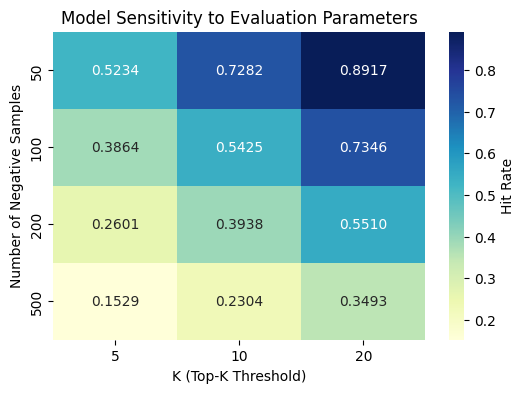

In [26]:

# Evaluate the model's performance with different number of negatives per positive and different 
def metricSensitivity(model, test_df, full_df):
    neg_values = [50, 100, 200, 500] 
    k_values = [5, 10, 20]
    results = []
    print("Executing Evaluation Grid Search")
    
    for neg in neg_values:
        for k in k_values:
            hit_rate = hit_at_k(model, test_df, full_df, K=k, num_neg=neg)
            results.append({'Num_Negatives': neg, 'K': k, 'Hit_Rate': hit_rate})
            print(f"Negatives={neg} | K={k} -> Hit@{k}: {hit_rate}")

    results_df = pd.DataFrame(results)
    pivot_df = results_df.pivot(index='Num_Negatives', columns='K', values='Hit_Rate')
    
    print("\n--- Hit Rate Matrix ---")
    print(pivot_df)
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Hit Rate'})
    plt.title("Model Sensitivity to Evaluation Parameters")
    plt.ylabel("Number of Negative Samples")
    plt.xlabel("K (Top-K Threshold)")
    plt.show()


metricSensitivity(MF_model, test_df, df)

In [19]:
rate = hit_at_k(MF_model, test_df, df, K=10, num_neg=100)
print(f"Hit@10: {rate:.4f}")

Hit@10: 0.1051


User PCA Explained Variance: 0.1587
Item PCA Explained Variance: 0.1488


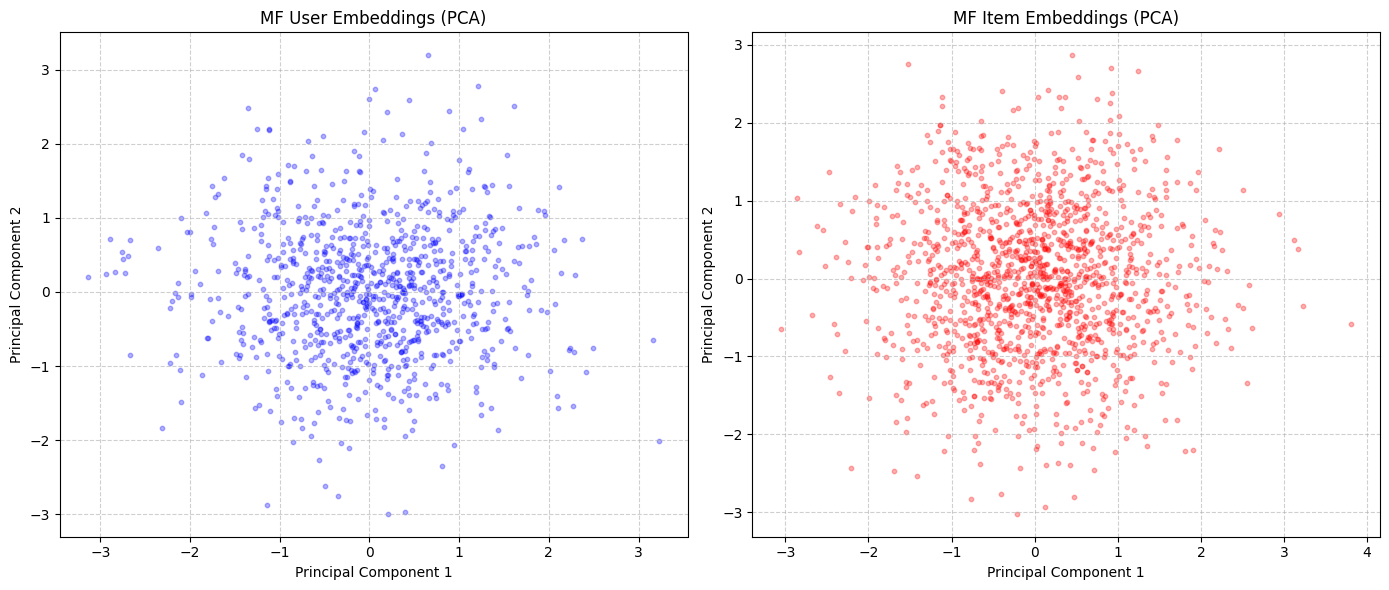

In [20]:
def visualize_mf_embeddings(model):
    mf_item_embs = model.item_emb.weight.detach().cpu().numpy()
    mf_user_embs = model.user_emb.weight.detach().cpu().numpy()

    # 2. Fit PCA to reduce the K-dimensional space to 2D
    pca_users = PCA(n_components=2)
    user_2d = pca_users.fit_transform(mf_user_embs)
    
    pca_items = PCA(n_components=2)
    item_2d = pca_items.fit_transform(mf_item_embs)

    # 3. Print variance ratios to see how much signal is preserved in 2D
    print(f"User PCA Explained Variance: {np.sum(pca_users.explained_variance_ratio_):.4f}")
    print(f"Item PCA Explained Variance: {np.sum(pca_items.explained_variance_ratio_):.4f}")

    # 4. Plot the geometries
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # User Plot
    axes[0].scatter(user_2d[:, 0], user_2d[:, 1], alpha=0.3, color='blue', s=10)
    axes[0].set_title("MF User Embeddings (PCA)")
    axes[0].set_xlabel("Principal Component 1")
    axes[0].set_ylabel("Principal Component 2")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Item Plot
    axes[1].scatter(item_2d[:, 0], item_2d[:, 1], alpha=0.3, color='red', s=10)
    axes[1].set_title("MF Item Embeddings (PCA)")
    axes[1].set_xlabel("Principal Component 1")
    axes[1].set_ylabel("Principal Component 2")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Execute the visualization
visualize_mf_embeddings(MF_model)

If your score is low, try playing with the hyperparameters before moving on! Try sampling more negatives, or playing with the embedding dimensions.

Conversely, if your score is high, play with the values of K or number of negatives in evaluation (dec K, inc negatives).

## Neural Model: MLP-Based Recommender

Instead of using a dot product, we can learn a more flexible interaction function using a neural network.

Approach:
- Learn user and item embeddings
- **Concatenate** them
- Pass through a **Multi-Layer Perceptron (MLP)**

This allows the model to capture more complex relationships than simple similarity.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Concatenates them
3. Passes them through an MLP to produce a score

The choice of activation functions is upto you.

In [21]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        # TODO:
        # - Define user embedding layer
        # - Define item embedding layer
        # - Define MLP layers

        # Aditionla complexity are useless for big dataset like this

        self.user_emb=nn.Embedding(num_users, emb_dim)
        self.item_emb=nn.Embedding(num_items, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, user, item):
        # TODO:
        # - Get embeddings
        # - Concatenate user and item embeddings
        # - Pass through MLP
        # - Return a single score
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        concatenated = torch.cat([user_emb, item_emb], dim=1)
        return self.mlp(concatenated)[:,0]

## Train and Evaluate the MLP Model

Repeat the same steps as before:
- Train the model
- Evaluate on the test set

Compare its performance with the MF model.

In [22]:
# TODO:
# 1. Initialize MLP model
# 2. Train it
# 3. Evaluate it
MLP_model = MLP(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=32)

train(MLP_model, train_loader,epochs=150, val_dataloader=valid_loader, val_hit_dataloader=valid_hit_loader,num_items=df['item_id'].nunique())


Epoch 1: Train Loss: 0.2715 | Val Loss: 0.2325 | Val Hit@10: 0.5276
Epoch 2: Train Loss: 0.2272 | Val Loss: 0.2303 | Val Hit@10: 0.5425
Epoch 3: Train Loss: 0.2239 | Val Loss: 0.2285 | Val Hit@10: 0.5456
Epoch 4: Train Loss: 0.2219 | Val Loss: 0.2270 | Val Hit@10: 0.5510
Epoch 5: Train Loss: 0.2206 | Val Loss: 0.2274 | Val Hit@10: 0.5456
Epoch 6: Train Loss: 0.2188 | Val Loss: 0.2268 | Val Hit@10: 0.5499
Epoch 7: Train Loss: 0.2144 | Val Loss: 0.2261 | Val Hit@10: 0.5552
Epoch 8: Train Loss: 0.2121 | Val Loss: 0.2271 | Val Hit@10: 0.5711
Epoch 9: Train Loss: 0.2100 | Val Loss: 0.2247 | Val Hit@10: 0.5754
Epoch 10: Train Loss: 0.2073 | Val Loss: 0.2267 | Val Hit@10: 0.5732
Epoch 11: Train Loss: 0.2045 | Val Loss: 0.2270 | Val Hit@10: 0.5764
Epoch 12: Train Loss: 0.2020 | Val Loss: 0.2232 | Val Hit@10: 0.5817
Epoch 13: Train Loss: 0.1992 | Val Loss: 0.2251 | Val Hit@10: 0.5966
Epoch 14: Train Loss: 0.1971 | Val Loss: 0.2258 | Val Hit@10: 0.5987
Epoch 15: Train Loss: 0.1945 | Val Loss: 0.

[0.2714525965763175,
 0.22719355277393175,
 0.22386947515218153,
 0.2218671870490779,
 0.22064394563436507,
 0.2187700642839722,
 0.2143913959161095,
 0.21211733337329783,
 0.21000137881092404,
 0.2072553321071293,
 0.20448843524507854,
 0.20197840763174968,
 0.19921914616356726,
 0.19714459310407223,
 0.19450289380291233,
 0.1925527888406878,
 0.18935110206189362,
 0.18824201801548834,
 0.1864658811364485,
 0.18543878254683122,
 0.184584618087696,
 0.1824326775708924]

Executing Evaluation Grid Search
Negatives=50 | K=5 -> Hit@5: 0.60828025477707
Negatives=50 | K=10 -> Hit@10: 0.7791932059447984
Negatives=50 | K=20 -> Hit@20: 0.9065817409766455
Negatives=100 | K=5 -> Hit@5: 0.4596602972399151
Negatives=100 | K=10 -> Hit@10: 0.6210191082802548
Negatives=100 | K=20 -> Hit@20: 0.7919320594479831
Negatives=200 | K=5 -> Hit@5: 0.3333333333333333
Negatives=200 | K=10 -> Hit@10: 0.4851380042462845
Negatives=200 | K=20 -> Hit@20: 0.6316348195329087
Negatives=500 | K=5 -> Hit@5: 0.20063694267515925
Negatives=500 | K=10 -> Hit@10: 0.30254777070063693
Negatives=500 | K=20 -> Hit@20: 0.43630573248407645

--- Hit Rate Matrix ---
K                    5         10        20
Num_Negatives                              
50             0.608280  0.779193  0.906582
100            0.459660  0.621019  0.791932
200            0.333333  0.485138  0.631635
500            0.200637  0.302548  0.436306


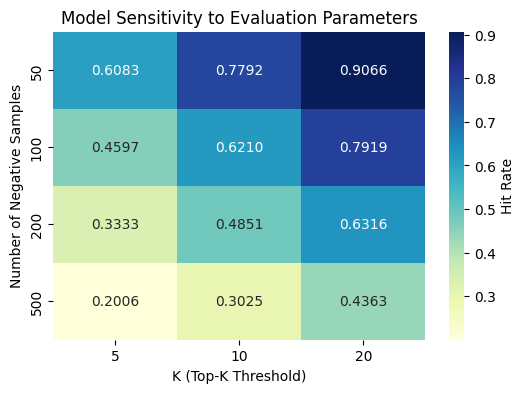

Hit@10: 0.6157


In [23]:
hit_rate = hit_at_k(MLP_model, test_df, df, K=10, num_neg=100)
metricSensitivity(MLP_model, test_df, df)
torch.save(MLP_model.state_dict(), 'mlp_pretrained.pth')
print(f"Hit@10: {hit_rate:.4f}")


## Comparison & Analysis

You have now implemented:
- Matrix Factorization (MF)
- MLP-based recommender

---

### Compare the Models

- What score did each model achieve?
- Which model performed better?

---

### Think & Reflect

- Why might the MLP model outperform MF?
- In what cases might MF perform just as well or better?
- How does embedding size affect performance?
- Did you observe any signs of overfitting?

---

### Some Experiments

If you want to explore further:
- Try different embedding dimensions
- Change number of MLP layers
- Try different activation functions

---

## Bonus Task: Neural Collaborative Filtering (NCF)

In this task, you implemented:
- Matrix Factorization (MF)
- MLP-based recommender

The paper [Neural Collaborative Filtering](https://arxiv.org/pdf/1708.05031) proposes combining both ideas.

---

### Idea

- MF captures **linear interactions**
- MLP captures **nonlinear interactions**

NCF combines both by:
1. Computing MF output
2. Computing MLP output
3. Combining them into a final prediction

---

### Your Task

Design a model that:
- Uses both MF and MLP components
- Combines their outputs
- Trains end-to-end

---

### Hints

- You can:
  - Concatenate MF and MLP representations
  - Or combine their final scores
- Think about:
  - Should embeddings be shared or separate?
  - How to balance both components?

---

Does combining both approaches improve performance over MF and MLP individually?

In [27]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, mf_dim=16, mlp_dim=32, layers=[64, 32, 16]):
        super().__init__()

        self.mf_user_emb = nn.Embedding(num_users, mf_dim)
        self.mf_item_emb = nn.Embedding(num_items, mf_dim)

        self.mlp_user_emb = nn.Embedding(num_users, mlp_dim)
        self.mlp_item_emb = nn.Embedding(num_items, mlp_dim)

        for emb in [self.mf_user_emb, self.mf_item_emb, self.mlp_user_emb, self.mlp_item_emb]:
            nn.init.normal_(emb.weight, std=0.1)

        mlp_layers = []
        input_dim = 2 * mlp_dim
        for hidden_dim in layers:
            mlp_layers.append(nn.Linear(input_dim, hidden_dim))
            mlp_layers.append(nn.ReLU())
            input_dim = hidden_dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.predict_layer = nn.Linear(mf_dim + layers[-1], 1)

    def forward(self, user, item):
        mf_output = self.mf_user_emb(user) * self.mf_item_emb(item)

        mlp_input = torch.cat([self.mlp_user_emb(user), self.mlp_item_emb(item)], dim=1)
        mlp_output = self.mlp(mlp_input)

        combined = torch.cat([mf_output, mlp_output], dim=1)
        return self.predict_layer(combined).squeeze(-1)


In [28]:
from pathlib import Path

NCF_model = NeuMF(
    num_users=df['user_id'].nunique(),
    num_items=df['item_id'].nunique(),
    mf_dim=16,
    mlp_dim=32,
    layers=[64, 32, 16]
)

gmf_path = Path('gmf_pretrained.pth')
mlp_path = Path('mlp_pretrained.pth')

if gmf_path.exists() and mlp_path.exists():
    gmf_state = torch.load(gmf_path, map_location='cpu')
    mlp_state = torch.load(mlp_path, map_location='cpu')

    with torch.no_grad():
        NCF_model.mf_user_emb.weight.copy_(gmf_state['user_emb.weight'])
        NCF_model.mf_item_emb.weight.copy_(gmf_state['item_emb.weight'])
        NCF_model.mlp_user_emb.weight.copy_(mlp_state['user_emb.weight'])
        NCF_model.mlp_item_emb.weight.copy_(mlp_state['item_emb.weight'])

    print('Loaded MF and MLP embeddings into NeuMF.')
else:
    print('Pretrained MF/MLP weights not found. Training NeuMF from scratch.')

train(
    NCF_model,
    train_loader,
    epochs=60,
    val_dataloader=valid_loader,
    val_hit_dataloader=valid_hit_loader,
    lr=5e-4,
    patience=5,
    num_items=df['item_id'].nunique()
)


Loaded MF and MLP embeddings into NeuMF.
Epoch 1: Train Loss: 0.2479 | Val Loss: 0.2192 | Val Hit@10: 0.5786
Epoch 2: Train Loss: 0.1992 | Val Loss: 0.2133 | Val Hit@10: 0.5987
Epoch 3: Train Loss: 0.1906 | Val Loss: 0.2160 | Val Hit@10: 0.6093
Epoch 4: Train Loss: 0.1843 | Val Loss: 0.2186 | Val Hit@10: 0.6306
Epoch 5: Train Loss: 0.1790 | Val Loss: 0.2184 | Val Hit@10: 0.6306
Epoch 6: Train Loss: 0.1747 | Val Loss: 0.2136 | Val Hit@10: 0.6210
Epoch 7: Train Loss: 0.1703 | Val Loss: 0.2191 | Val Hit@10: 0.6348
Epoch 8: Train Loss: 0.1666 | Val Loss: 0.2211 | Val Hit@10: 0.6210
Epoch 9: Train Loss: 0.1635 | Val Loss: 0.2272 | Val Hit@10: 0.6274
Epoch 10: Train Loss: 0.1603 | Val Loss: 0.2242 | Val Hit@10: 0.6221
Epoch 11: Train Loss: 0.1568 | Val Loss: 0.2255 | Val Hit@10: 0.6274
Epoch 12: Train Loss: 0.1548 | Val Loss: 0.2243 | Val Hit@10: 0.6359
Epoch 13: Train Loss: 0.1539 | Val Loss: 0.2258 | Val Hit@10: 0.6348
Epoch 14: Train Loss: 0.1517 | Val Loss: 0.2256 | Val Hit@10: 0.6306
Ep

[0.24791367655215055,
 0.19923295907352281,
 0.19063137121822524,
 0.18433350512514943,
 0.17903625419606334,
 0.1746869394507097,
 0.17030878170676853,
 0.16663229738888533,
 0.1635157944391603,
 0.16029306292533874,
 0.15681315972753193,
 0.15478039870443552,
 0.15387094513229702,
 0.15171519381844478,
 0.1508083344736825,
 0.14841346796440041,
 0.148053916381753,
 0.14679946895526802,
 0.1460820569227571,
 0.1453574013321296,
 0.14541758349408274]

Executing Evaluation Grid Search
Negatives=50 | K=5 -> Hit@5: 0.6751592356687898
Negatives=50 | K=10 -> Hit@10: 0.8248407643312102
Negatives=50 | K=20 -> Hit@20: 0.9394904458598726
Negatives=100 | K=5 -> Hit@5: 0.5191082802547771
Negatives=100 | K=10 -> Hit@10: 0.6910828025477707
Negatives=100 | K=20 -> Hit@20: 0.8386411889596603
Negatives=200 | K=5 -> Hit@5: 0.37048832271762205
Negatives=200 | K=10 -> Hit@10: 0.5329087048832272
Negatives=200 | K=20 -> Hit@20: 0.6836518046709129
Negatives=500 | K=5 -> Hit@5: 0.23354564755838642
Negatives=500 | K=10 -> Hit@10: 0.3503184713375796
Negatives=500 | K=20 -> Hit@20: 0.4745222929936306

--- Hit Rate Matrix ---
K                    5         10        20
Num_Negatives                              
50             0.675159  0.824841  0.939490
100            0.519108  0.691083  0.838641
200            0.370488  0.532909  0.683652
500            0.233546  0.350318  0.474522


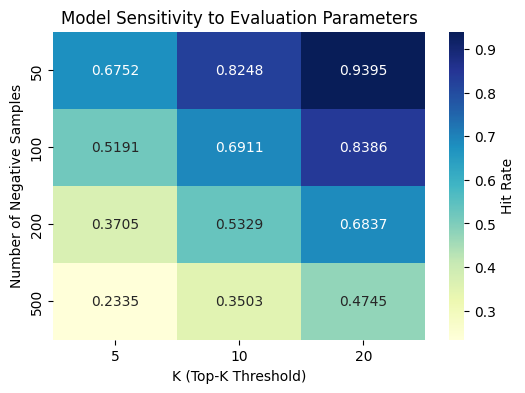

,Model,Hit@10
0,NeuMF,0.680467
1,MLP,0.618896
2,MF,0.537155


NeuMF improves over both standalone models with Hit@10 = 0.6805.
MF Hit@10: 0.5372
MLP Hit@10: 0.6189
NeuMF Hit@10: 0.6805


In [29]:
np.random.seed(seed)
mf_hit_rate = hit_at_k(MF_model, test_df, df, K=10, num_neg=100)
np.random.seed(seed)
mlp_hit_rate = hit_at_k(MLP_model, test_df, df, K=10, num_neg=100)
np.random.seed(seed)
ncf_hit_rate = hit_at_k(NCF_model, test_df, df, K=10, num_neg=100)

metricSensitivity(NCF_model, test_df, df)
torch.save(NCF_model.state_dict(), 'neumf_pretrained.pth')

comparison_df = pd.DataFrame(
    {
        'Model': ['MF', 'MLP', 'NeuMF'],
        'Hit@10': [mf_hit_rate, mlp_hit_rate, ncf_hit_rate]
    }
).sort_values('Hit@10', ascending=False).reset_index(drop=True)

display(comparison_df)

best_model = comparison_df.loc[0, 'Model']
if best_model == 'NeuMF':
    print(f'NeuMF improves over both standalone models with Hit@10 = {ncf_hit_rate:.4f}.')
else:
    print(f'NeuMF does not beat both standalone models here. Best model: {best_model}.')

print(f'MF Hit@10: {mf_hit_rate:.4f}')
print(f'MLP Hit@10: {mlp_hit_rate:.4f}')
print(f'NeuMF Hit@10: {ncf_hit_rate:.4f}')
